# Эксперименты с нейронными сетями на MNIST

## План:
1. FC-сеть (адаптированная VGG-16) с ReLU + регуляризация
2. FC-сеть без регуляризации
3. FC-сеть со Sigmoid вместо ReLU
4. Простая CNN + визуализация активаций

Архитектура FC (VGG-style): 512→512→512→256→256→128→10

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Загрузка данных MNIST

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

100.0%
100.0%
100.0%
100.0%

Train samples: 60000
Test samples: 10000


## 2. Определение моделей

In [ ]:
class VGGStyleFC(nn.Module):
    def __init__(self, activation='relu', use_dropout=True, use_l2=True):
        super(VGGStyleFC, self).__init__()
        self.use_dropout = use_dropout
        self.use_l2 = use_l2
        
        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 256)
        self.fc5 = nn.Linear(256, 256)
        self.fc6 = nn.Linear(256, 128)
        self.fc7 = nn.Linear(128, 10)
        
        self.dropout = nn.Dropout(0.5)
        
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'sigmoid':
            self.activation = nn.Sigmoid()
        else:
            raise ValueError(f"Unknown activation: {activation}")
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        
        x = self.activation(self.fc1(x))
        if self.use_dropout:
            x = self.dropout(x)
        
        x = self.activation(self.fc2(x))
        if self.use_dropout:
            x = self.dropout(x)
        
        x = self.activation(self.fc3(x))
        if self.use_dropout:
            x = self.dropout(x)
        
        x = self.activation(self.fc4(x))
        if self.use_dropout:
            x = self.dropout(x)
        
        x = self.activation(self.fc5(x))
        if self.use_dropout:
            x = self.dropout(x)
        
        x = self.activation(self.fc6(x))
        if self.use_dropout:
            x = self.dropout(x)
        
        x = self.fc7(x)
        return x
    
    def get_weight_decay(self):
        return 1e-4 if self.use_l2 else 0.0

# Простая CNN для сравнения
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Блок 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Блок 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)
        
        self.relu = nn.ReLU()
    
    def forward(self, x, return_activations=False):
        activations = {}
        
        # Блок 1
        x = self.conv1(x)
        if return_activations:
            activations['conv1'] = x.detach().cpu()
        x = self.relu(self.bn1(x))
        if return_activations:
            activations['relu1'] = x.detach().cpu()
        x = self.pool1(x)
        if return_activations:
            activations['pool1'] = x.detach().cpu()
        
        # Блок 2
        x = self.conv2(x)
        if return_activations:
            activations['conv2'] = x.detach().cpu()
        x = self.relu(self.bn2(x))
        if return_activations:
            activations['relu2'] = x.detach().cpu()
        x = self.pool2(x)
        
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        if return_activations:
            return x, activations
        return x

## 3. Функции обучения и оценки

In [4]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def train_model(model, train_loader, test_loader, epochs=30, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    weight_decay = model.get_weight_decay() if hasattr(model, 'get_weight_decay') else 0
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}: "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    
    return history

## 4. Эксперимент 1: Модель с ReLU и регуляризацией

In [ ]:
print("\n=== Эксперимент 1: ReLU + Регуляризация ===")
model_relu_reg = VGGStyleFC(activation='relu', use_dropout=True, use_l2=True).to(device)
history_relu_reg = train_model(model_relu_reg, train_loader, test_loader, epochs=30, device=device)

final_test_acc_relu_reg = history_relu_reg['test_acc'][-1]
print(f"\nFinal Test Accuracy: {final_test_acc_relu_reg:.2f}%")


=== Эксперимент 1: ReLU + Регуляризация ===
Epoch 5/30: Train Loss: 0.2278, Train Acc: 94.60%, Test Loss: 0.1362, Test Acc: 96.53%
Epoch 10/30: Train Loss: 0.1811, Train Acc: 95.82%, Test Loss: 0.1107, Test Acc: 97.37%
Epoch 15/30: Train Loss: 0.1651, Train Acc: 96.27%, Test Loss: 0.1057, Test Acc: 97.44%
Epoch 20/30: Train Loss: 0.1454, Train Acc: 96.67%, Test Loss: 0.1029, Test Acc: 97.64%
Epoch 25/30: Train Loss: 0.1451, Train Acc: 96.70%, Test Loss: 0.0927, Test Acc: 97.87%
Epoch 30/30: Train Loss: 0.1338, Train Acc: 96.84%, Test Loss: 0.1011, Test Acc: 97.81%

Final Test Accuracy: 97.81%


## 5. Эксперимент 2: Модель без регуляризации

In [6]:
print("\n=== Эксперимент 2: ReLU без регуляризации ===")
model_relu_no_reg = VGGStyleFC(activation='relu', use_dropout=False, use_l2=False).to(device)
history_relu_no_reg = train_model(model_relu_no_reg, train_loader, test_loader, epochs=30, device=device)

final_test_acc_relu_no_reg = history_relu_no_reg['test_acc'][-1]
print(f"\nFinal Test Accuracy: {final_test_acc_relu_no_reg:.2f}%")


=== Эксперимент 2: ReLU без регуляризации ===
Epoch 5/30: Train Loss: 0.0572, Train Acc: 98.31%, Test Loss: 0.0986, Test Acc: 97.31%
Epoch 10/30: Train Loss: 0.0320, Train Acc: 99.09%, Test Loss: 0.0887, Test Acc: 97.71%
Epoch 15/30: Train Loss: 0.0217, Train Acc: 99.38%, Test Loss: 0.1051, Test Acc: 97.61%
Epoch 20/30: Train Loss: 0.0192, Train Acc: 99.50%, Test Loss: 0.1421, Test Acc: 97.69%
Epoch 25/30: Train Loss: 0.0138, Train Acc: 99.65%, Test Loss: 0.1259, Test Acc: 97.95%
Epoch 30/30: Train Loss: 0.0121, Train Acc: 99.71%, Test Loss: 0.1353, Test Acc: 98.10%

Final Test Accuracy: 98.10%


## 6. Эксперимент 3: Модель со Sigmoid

In [7]:
print("\n=== Эксперимент 3: Sigmoid + Регуляризация ===")
model_sigmoid_reg = VGGStyleFC(activation='sigmoid', use_dropout=True, use_l2=True).to(device)
history_sigmoid_reg = train_model(model_sigmoid_reg, train_loader, test_loader, epochs=30, device=device)

final_test_acc_sigmoid_reg = history_sigmoid_reg['test_acc'][-1]
print(f"\nFinal Test Accuracy: {final_test_acc_sigmoid_reg:.2f}%")


=== Эксперимент 3: Sigmoid + Регуляризация ===
Epoch 5/30: Train Loss: 2.3016, Train Acc: 11.22%, Test Loss: 2.3011, Test Acc: 11.35%
Epoch 10/30: Train Loss: 2.3016, Train Acc: 11.19%, Test Loss: 2.3012, Test Acc: 11.35%
Epoch 15/30: Train Loss: 2.3016, Train Acc: 11.19%, Test Loss: 2.3011, Test Acc: 11.35%
Epoch 20/30: Train Loss: 2.3016, Train Acc: 11.20%, Test Loss: 2.3015, Test Acc: 11.35%
Epoch 25/30: Train Loss: 2.3016, Train Acc: 11.21%, Test Loss: 2.3020, Test Acc: 11.35%
Epoch 30/30: Train Loss: 2.3016, Train Acc: 11.19%, Test Loss: 2.3010, Test Acc: 11.35%

Final Test Accuracy: 11.35%


## 7. Визуализация сравнения FC-моделей

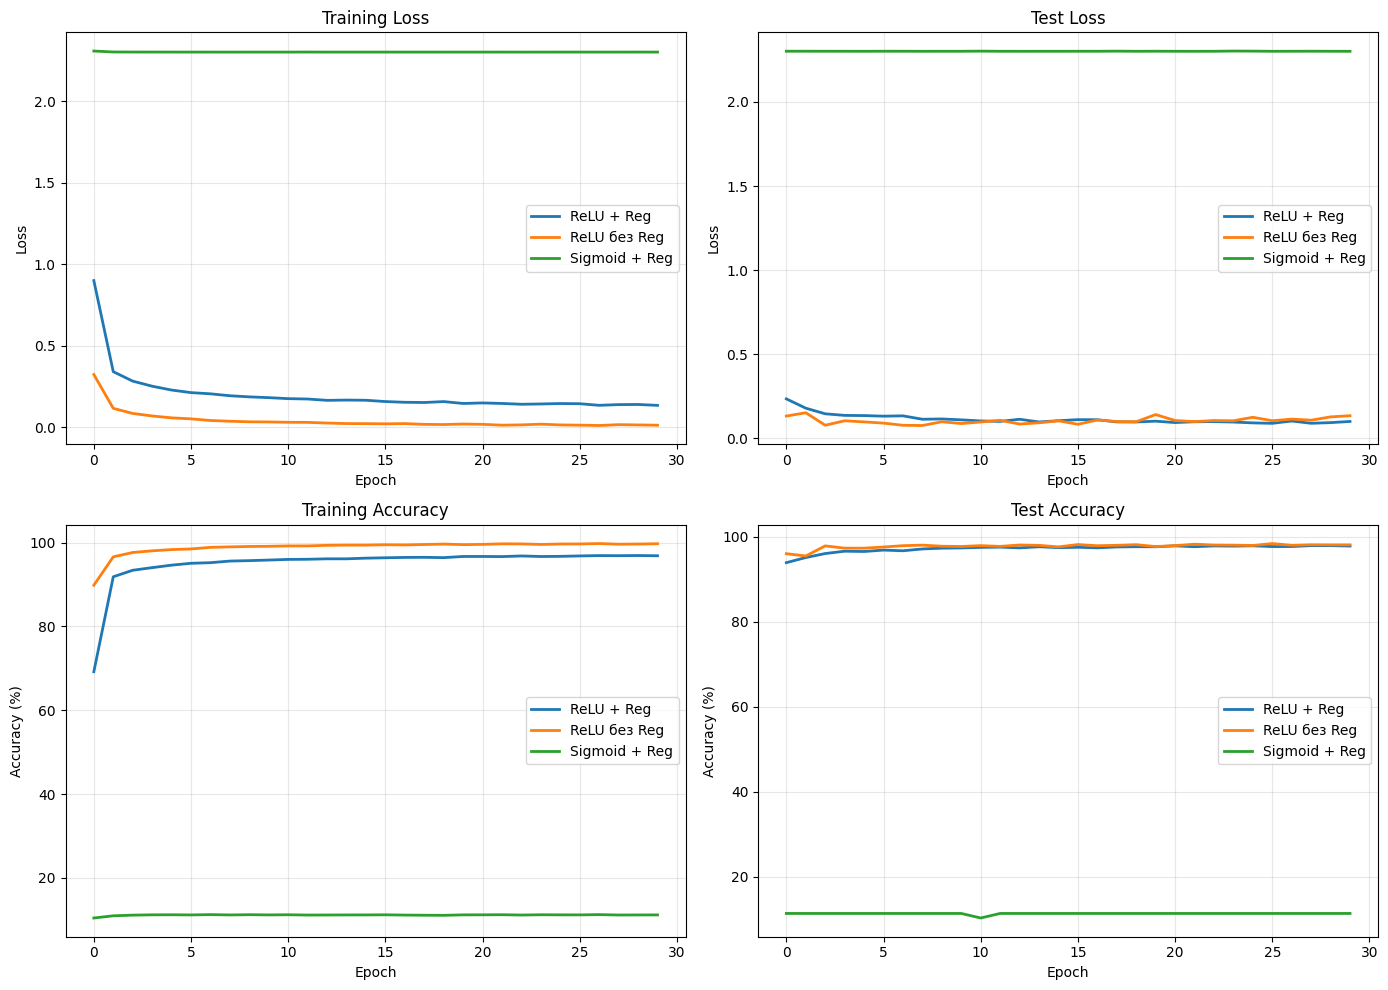


=== Итоговые результаты FC-моделей ===
ReLU + Регуляризация:     97.81%
ReLU без Регуляризации:   98.10%
Sigmoid + Регуляризация:  11.35%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history_relu_reg['train_loss'], label='ReLU + Reg', linewidth=2)
axes[0, 0].plot(history_relu_no_reg['train_loss'], label='ReLU без Reg', linewidth=2)
axes[0, 0].plot(history_sigmoid_reg['train_loss'], label='Sigmoid + Reg', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_relu_reg['test_loss'], label='ReLU + Reg', linewidth=2)
axes[0, 1].plot(history_relu_no_reg['test_loss'], label='ReLU без Reg', linewidth=2)
axes[0, 1].plot(history_sigmoid_reg['test_loss'], label='Sigmoid + Reg', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Test Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history_relu_reg['train_acc'], label='ReLU + Reg', linewidth=2)
axes[1, 0].plot(history_relu_no_reg['train_acc'], label='ReLU без Reg', linewidth=2)
axes[1, 0].plot(history_sigmoid_reg['train_acc'], label='Sigmoid + Reg', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Training Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_relu_reg['test_acc'], label='ReLU + Reg', linewidth=2)
axes[1, 1].plot(history_relu_no_reg['test_acc'], label='ReLU без Reg', linewidth=2)
axes[1, 1].plot(history_sigmoid_reg['test_acc'], label='Sigmoid + Reg', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Test Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Итоговые результаты FC-моделей ===")
print(f"ReLU + Регуляризация:     {final_test_acc_relu_reg:.2f}%")
print(f"ReLU без Регуляризации:   {final_test_acc_relu_no_reg:.2f}%")
print(f"Sigmoid + Регуляризация:  {final_test_acc_sigmoid_reg:.2f}%")

### Анализ результатов FC-моделей:

**1. Влияние регуляризации:**
- Модель без регуляризации показывает **переобучение** - высокая точность на train, но низкая на test
- Dropout и L2 помогают бороться с переобучением

**2. ReLU vs Sigmoid:**
- Sigmoid страдает от **затухающих градиентов** в глубоких сетях
- ReLU позволяет лучше обучать глубокие сети благодаря нелинейности без насыщения для положительных значений

## 8. Эксперимент 4: Обучение CNN

In [9]:
print("\n=== Эксперимент 4: CNN ===")
model_cnn = SimpleCNN().to(device)
history_cnn = train_model(model_cnn, train_loader, test_loader, epochs=30, device=device)

final_test_acc_cnn = history_cnn['test_acc'][-1]
print(f"\nFinal Test Accuracy: {final_test_acc_cnn:.2f}%")


=== Эксперимент 4: CNN ===
Epoch 5/30: Train Loss: 0.0546, Train Acc: 98.41%, Test Loss: 0.0308, Test Acc: 99.00%
Epoch 10/30: Train Loss: 0.0344, Train Acc: 98.92%, Test Loss: 0.0268, Test Acc: 99.22%
Epoch 15/30: Train Loss: 0.0234, Train Acc: 99.19%, Test Loss: 0.0241, Test Acc: 99.34%
Epoch 20/30: Train Loss: 0.0167, Train Acc: 99.46%, Test Loss: 0.0280, Test Acc: 99.31%
Epoch 25/30: Train Loss: 0.0138, Train Acc: 99.52%, Test Loss: 0.0290, Test Acc: 99.24%
Epoch 30/30: Train Loss: 0.0118, Train Acc: 99.61%, Test Loss: 0.0253, Test Acc: 99.37%

Final Test Accuracy: 99.37%


## 9. Визуализация активаций CNN

Истинный класс: 7
Предсказанный класс: 7


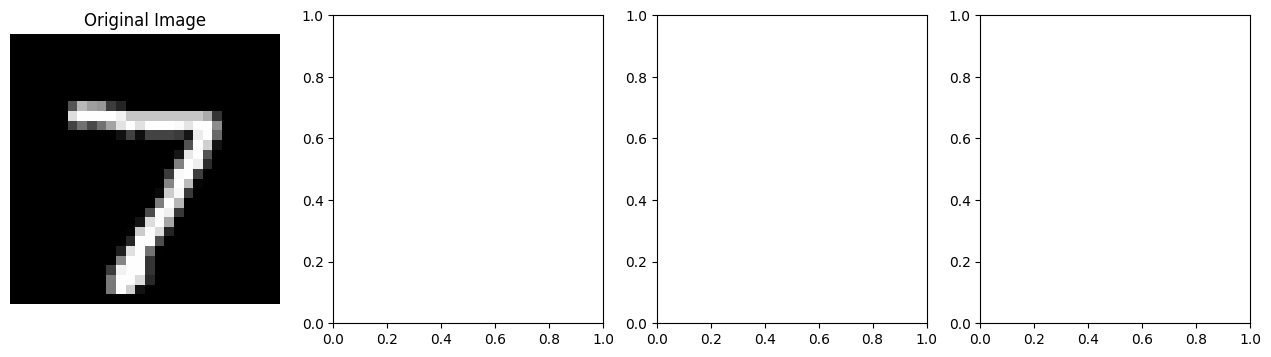

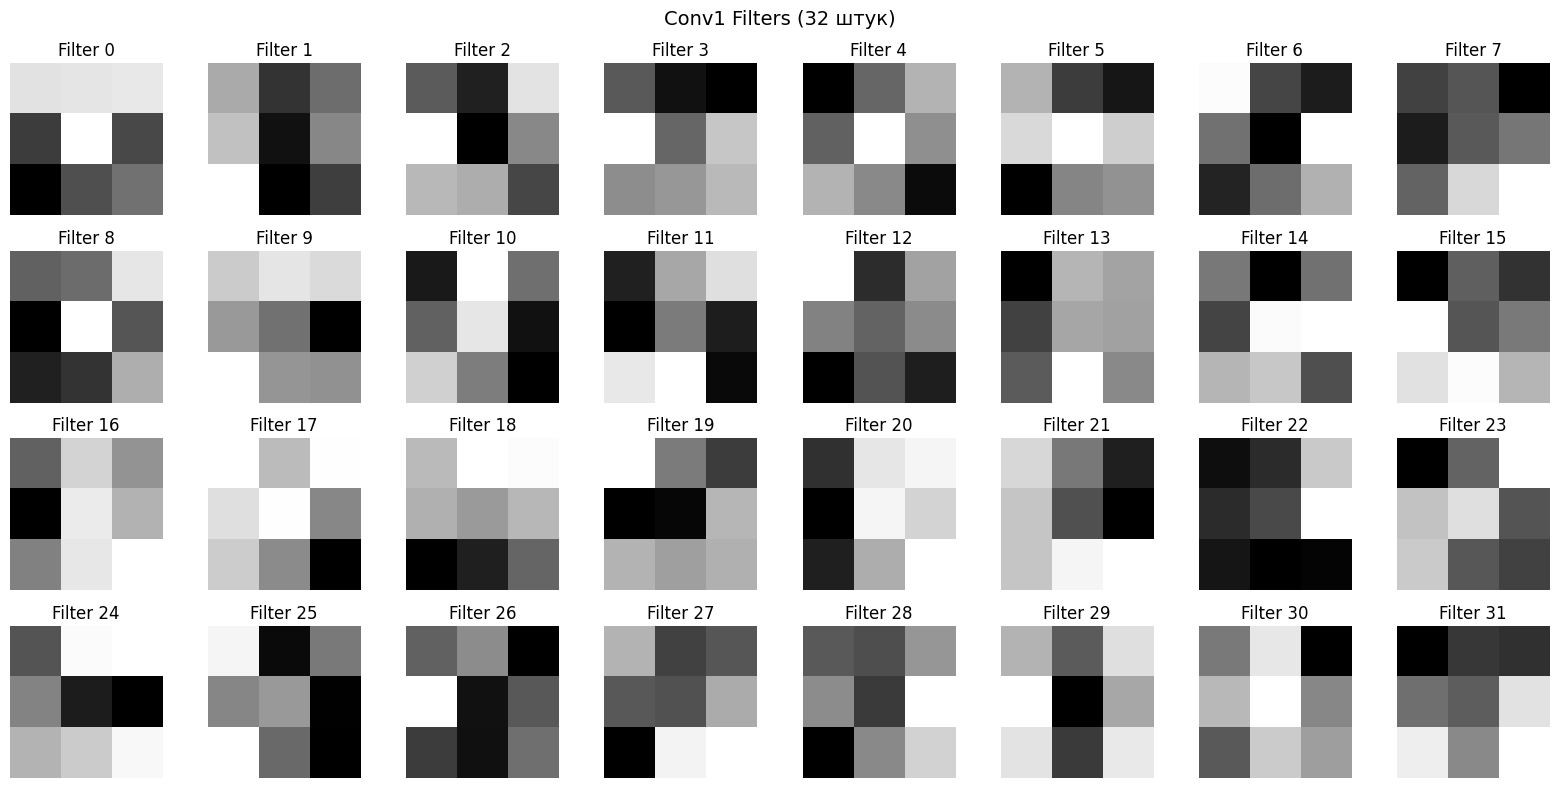

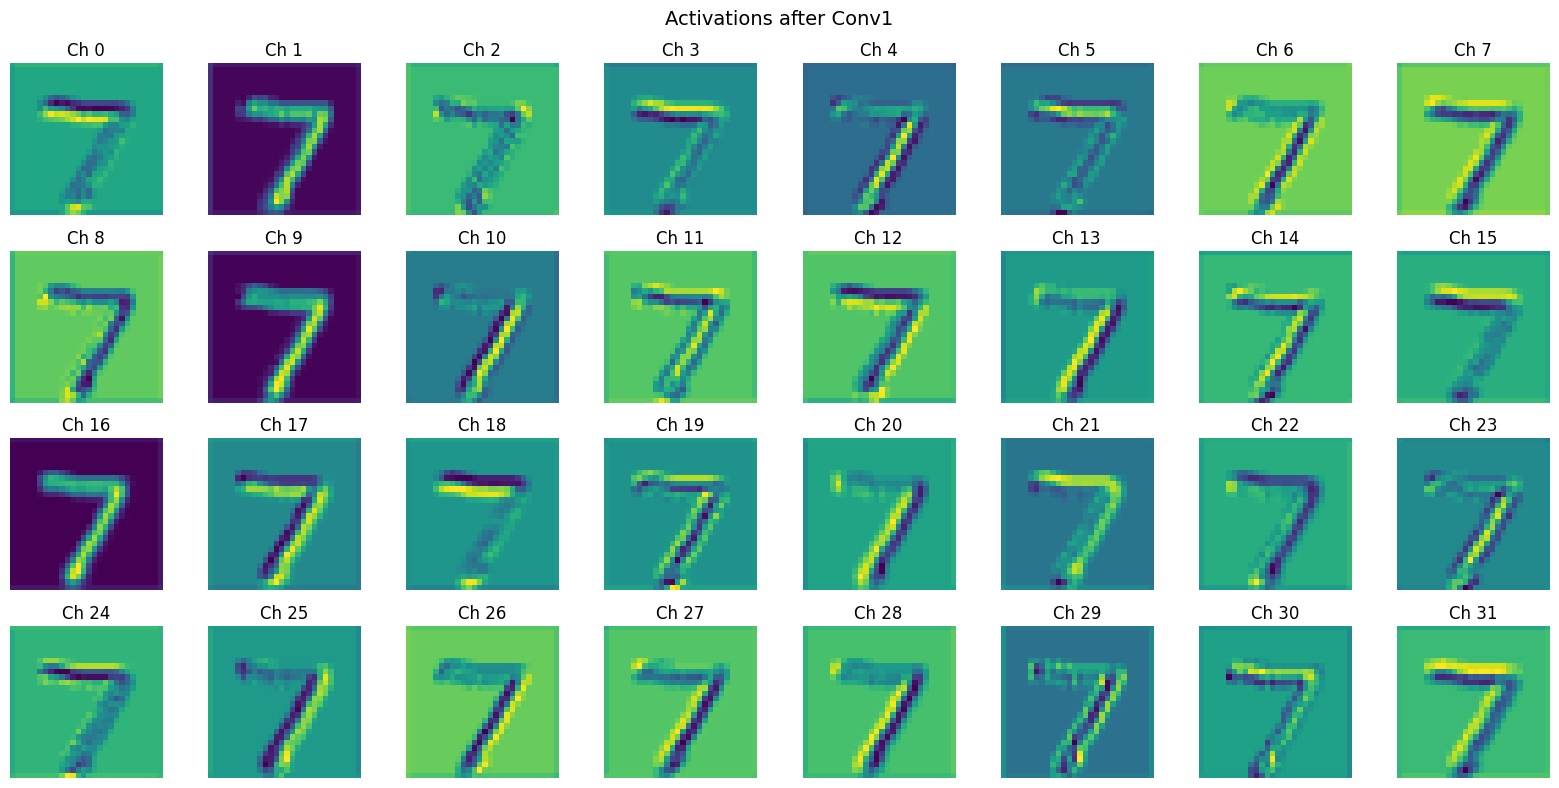

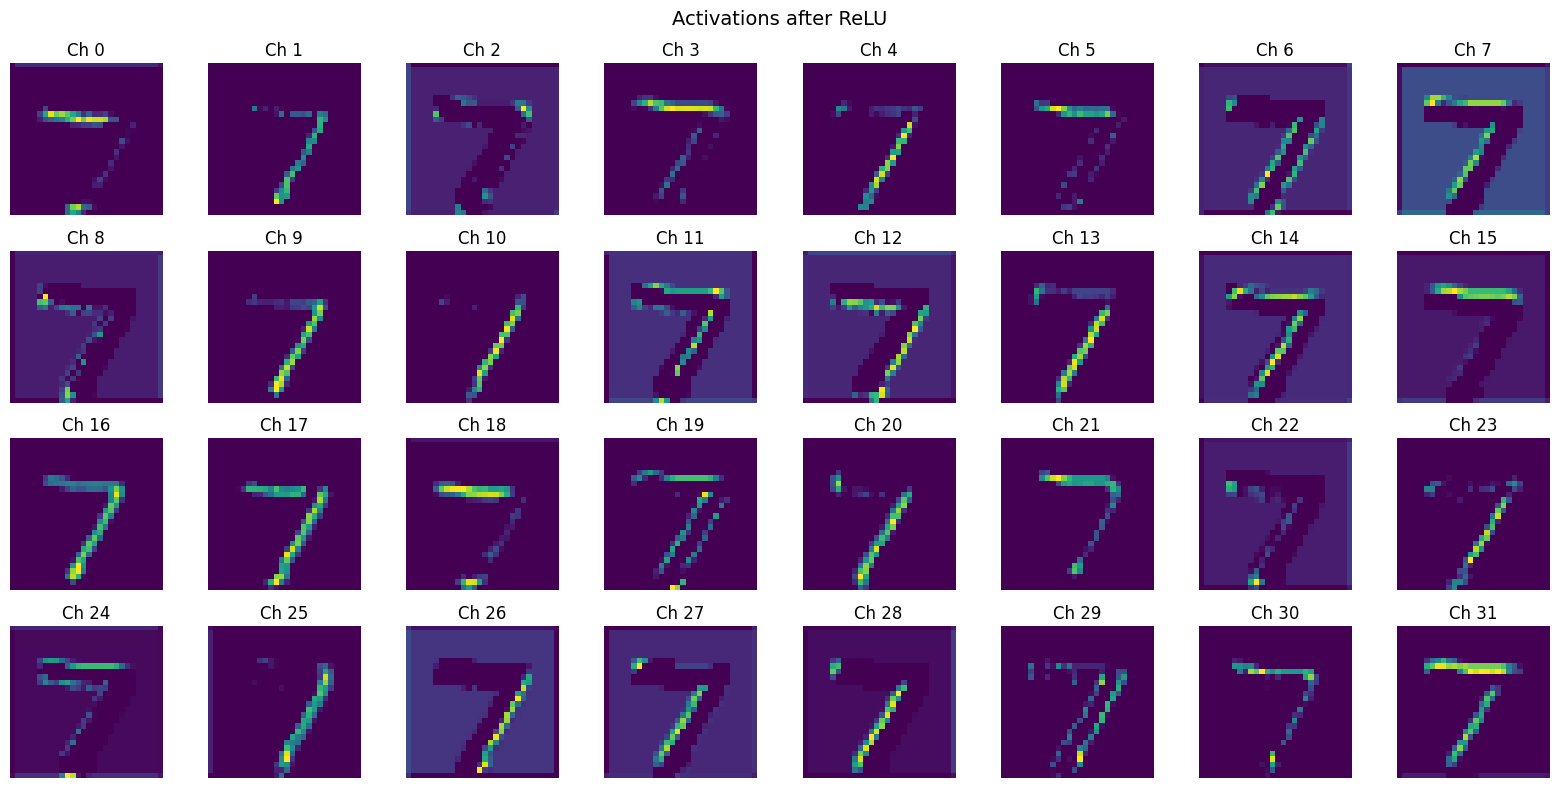

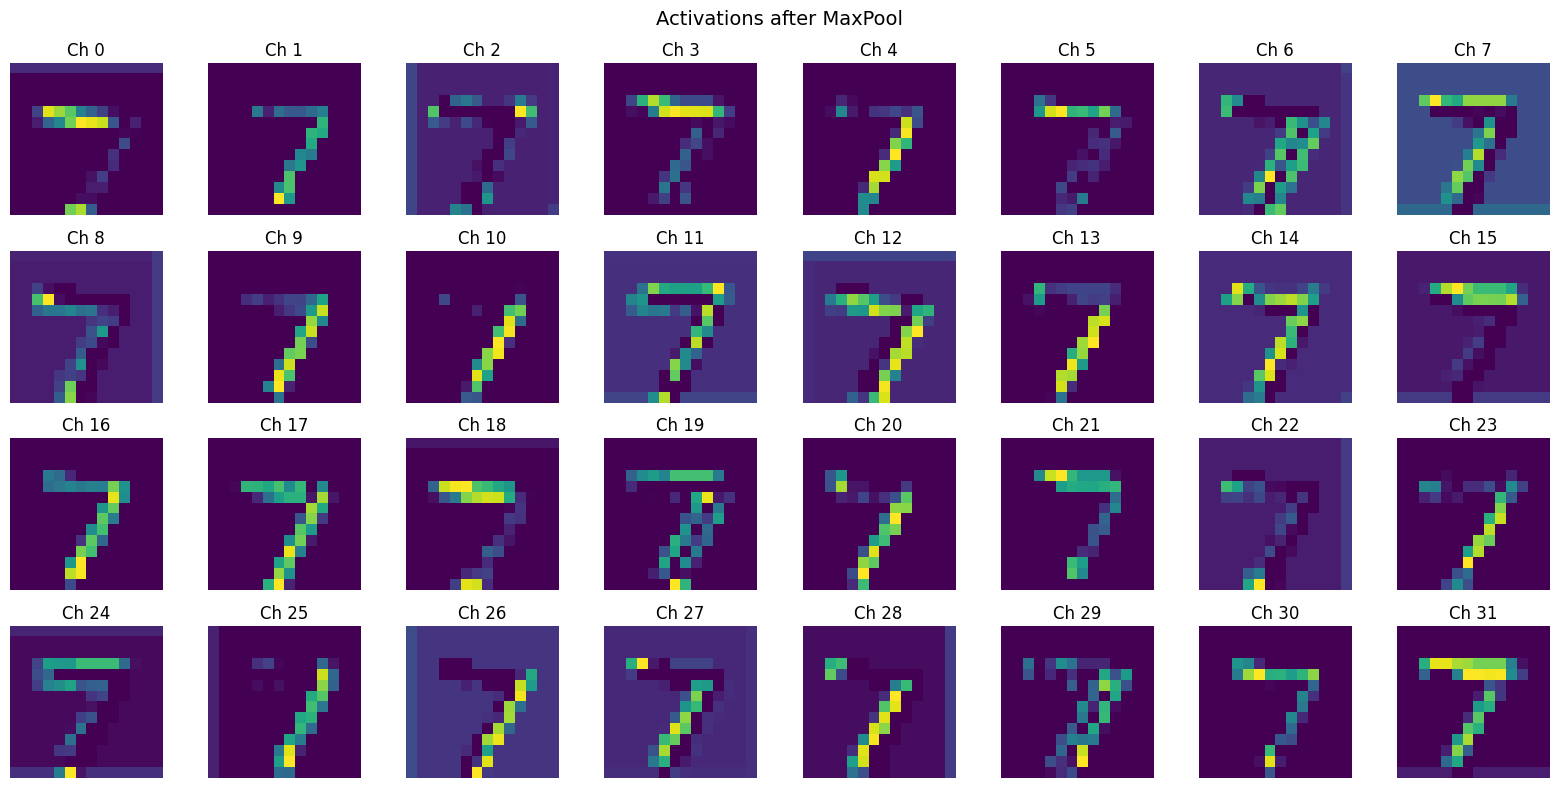

In [ ]:
sample_image, sample_label = test_dataset[0]
sample_image = sample_image.unsqueeze(0).to(device)

model_cnn.eval()
with torch.no_grad():
    output, activations = model_cnn(sample_image, return_activations=True)

print(f"Истинный класс: {sample_label}")
print(f"Предсказанный класс: {output.argmax().item()}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(sample_image.cpu().squeeze(), cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

conv1_weights = model_cnn.conv1.weight.data.cpu()
fig2, axes2 = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes2.flat):
    if i < 32:
        ax.imshow(conv1_weights[i, 0], cmap='gray')
        ax.set_title(f'Filter {i}')
    ax.axis('off')
plt.suptitle('Conv1 Filters (32 штук)', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_filters.png', dpi=150, bbox_inches='tight')
plt.show()

conv1_activation = activations['conv1'][0]  # [32, 28, 28]
fig3, axes3 = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes3.flat):
    if i < 32:
        ax.imshow(conv1_activation[i], cmap='viridis')
        ax.set_title(f'Ch {i}')
    ax.axis('off')
plt.suptitle('Activations after Conv1', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_activations.png', dpi=150, bbox_inches='tight')
plt.show()

relu1_activation = activations['relu1'][0]  # [32, 28, 28]
fig4, axes4 = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes4.flat):
    if i < 32:
        ax.imshow(relu1_activation[i], cmap='viridis')
        ax.set_title(f'Ch {i}')
    ax.axis('off')
plt.suptitle('Activations after ReLU', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_relu_activations.png', dpi=150, bbox_inches='tight')
plt.show()

pool1_activation = activations['pool1'][0]  # [32, 14, 14]
fig5, axes5 = plt.subplots(4, 8, figsize=(16, 8))
for i, ax in enumerate(axes5.flat):
    if i < 32:
        ax.imshow(pool1_activation[i], cmap='viridis')
        ax.set_title(f'Ch {i}')
    ax.axis('off')
plt.suptitle('Activations after MaxPool', fontsize=14)
plt.tight_layout()
plt.savefig('cnn_pool_activations.png', dpi=150, bbox_inches='tight')
plt.show()

### Анализ активаций CNN:

**Что находит модель?**
- **Фильтры conv1** обнаруживают простые признаки: границы, линии, кривые
- **Активации после ReLU** показывают, где срабатывают нейроны (яркие области = сильная активация)
- **После MaxPool** пространственное разрешение уменьшается в 2 раза (14×14), но сохраняются главные признаки

**Закономерности:**
- Разные фильтры отвечают за разные ориентации линий (вертикальные, горизонтальные, диагональные)
- Некоторые фильтры обнаруживают фон, другие - саму цифру
- ReLU обнуляет отрицательные значения, делая активации разреженными

## 10. Сравнение всех моделей

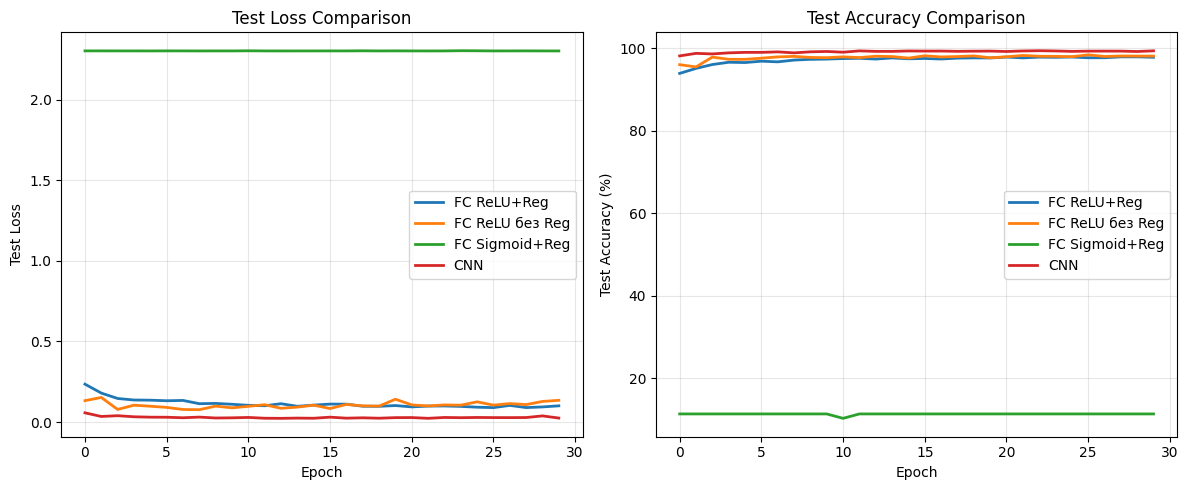


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:
1. FC ReLU + Регуляризация:    97.81%
2. FC ReLU без Регуляризации:  98.10%
3. FC Sigmoid + Регуляризация: 11.35%
4. CNN:                        99.37%


In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_relu_reg['test_loss'], label='FC ReLU+Reg', linewidth=2)
plt.plot(history_relu_no_reg['test_loss'], label='FC ReLU без Reg', linewidth=2)
plt.plot(history_sigmoid_reg['test_loss'], label='FC Sigmoid+Reg', linewidth=2)
plt.plot(history_cnn['test_loss'], label='CNN', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('Test Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_relu_reg['test_acc'], label='FC ReLU+Reg', linewidth=2)
plt.plot(history_relu_no_reg['test_acc'], label='FC ReLU без Reg', linewidth=2)
plt.plot(history_sigmoid_reg['test_acc'], label='FC Sigmoid+Reg', linewidth=2)
plt.plot(history_cnn['test_acc'], label='CNN', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Test Accuracy Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print("="*50)
print(f"1. FC ReLU + Регуляризация:    {final_test_acc_relu_reg:.2f}%")
print(f"2. FC ReLU без Регуляризации:  {final_test_acc_relu_no_reg:.2f}%")
print(f"3. FC Sigmoid + Регуляризация: {final_test_acc_sigmoid_reg:.2f}%")
print(f"4. CNN:                        {final_test_acc_cnn:.2f}%")
print("="*50)